# Plot some example fields from atmosphere, ocean and sea ice CFA files.

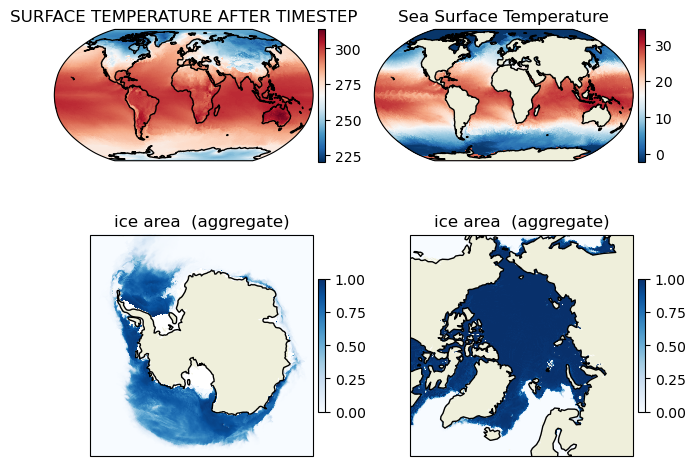

In [3]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cf

files = [
    "./CF-1.13_seed_CANARI_1_cv575_ATM_1_mon_m01s00i024_3.cfa",
    "./CF-1.13_seed_CANARI_1_cv575_OCN_day__grid_T_tos.cfa",
    "CF-1.13_seed_CANARI_1_cv575_CICE_day_aice.cfa",
] + [
    "CF-1.13_seed_CANARI_1_cv575_CICE_day_aice.cfa",
]

files = ['CFA-files/' + f for f in files]

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    layout="constrained",
)

if len(files) == 1:
    axes = [axes]
else:
    axes = axes.flatten()

cmaps = ["RdBu_r"] * 2 + ["Blues"] * 2

for i in range(len(files)):
    old_ax = axes[i]
    pos = old_ax.get_subplotspec()
    old_ax.remove()

    if i < 2:
        proj = ccrs.Robinson()
    elif i == 2:
        proj = ccrs.SouthPolarStereo()
    elif i == 3:
        proj = ccrs.NorthPolarStereo()

    ax = fig.add_subplot(pos, projection=proj)

    fields = cf.read(files[i])
    f = fields[0][0]  

    mesh = ax.pcolormesh(
        f.construct("X").data.array,
        f.construct("Y").data.array,
        f.data.array.squeeze(),
        transform=ccrs.PlateCarree(),
        shading="auto",
        cmap=cmaps[i],
        zorder=0,
    )

    ax.coastlines(resolution="110m", linewidth=1)

    if i == 2:
        ax.set_extent([-180, 180, -90 * (i == 2), -60 * (i == 2)], ccrs.PlateCarree())
    elif i == 3:
        ax.set_extent([-180, 180, 60, 90], ccrs.PlateCarree())
    else:
        ax.set_global()

    if i > 0:
        ax.add_feature(cfeature.LAND, zorder=1)

    plt.colorbar(mesh, ax=ax, orientation="vertical", pad=0.02, shrink=0.6)

    title_text = getattr(f, "long_name", f"File {i}")
    ax.set_title(title_text)

plt.show();